In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm

In [2]:

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [3]:


def plot(mean_dict, ci95_dict, length_dict, title, out_path, ylim=None):

    plt.rcParams.update({'font.size': 24})
    fig, ax = plt.subplots(figsize=(20,10))

    colour_list = ['royalblue', 'tomato', 'skyblue', 'lightsalmon', 'orange']

    for i, key in enumerate(mean_dict.keys()):
        colour = colour_list[i]
        mean = mean_dict[key]
        ci95 = ci95_dict[key]
        length = length_dict[key]
        width = len(mean)
        ax.plot(mean, color=colour, label=f"{key} (n={length:,})")
        ax.fill_between(np.arange(width), mean-ci95, mean+ci95,
                        color=colour, alpha=0.3)

    ax.set_title(title)
    ax.set_xlabel("Position")
    ax.set_ylabel(title)

    ax.set_xticks(np.arange(0, width, 3))
    ax.set_xticklabels(np.arange(0, width, 3))


    ## Vline at center
    ax.axvline(x=width//2, color="black", linestyle="--")

    ax.legend()
    if ylim is not None:
        ax.set_ylim(ylim)
    plt.savefig(f"{out_path}/{title}.pdf")
    plt.savefig(f"{out_path}/{title}.png", dpi=300)
    plt.show()
    plt.close()
    

    return None


In [6]:

feature_list = ["signal_mean","signal_median","signal_std","signal_len_log10","signal_amp","signal_rms","bq"]

ylim_dict = {}
ON0092_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0092/ON0092/result/dorado-070/intermediates/segmented_tokenized/signal_analysis_extended/sampled.pkl")
ON0096_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0096/result/dorado-070/intermediates/segmented_tokenized/signal_analysis_extended/sampled.pkl")
ON0099_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0099/result/dorado-070/intermediates/segmented_tokenized/signal_analysis_extended/sampled.pkl")

In [7]:
ON0118_df = pd.read_pickle(f"/extdata4/baeklab/Hyeonseo/m6A/runs/exp_BB87/ON0118/ON0118/result/intermediates/segmented_tokenized/signal_analysis_extended/sampled.pkl")
df_dict = {"ON0092": ON0092_df, "ON0096": ON0096_df, "ON0099": ON0099_df, "ON0118": ON0118_df}

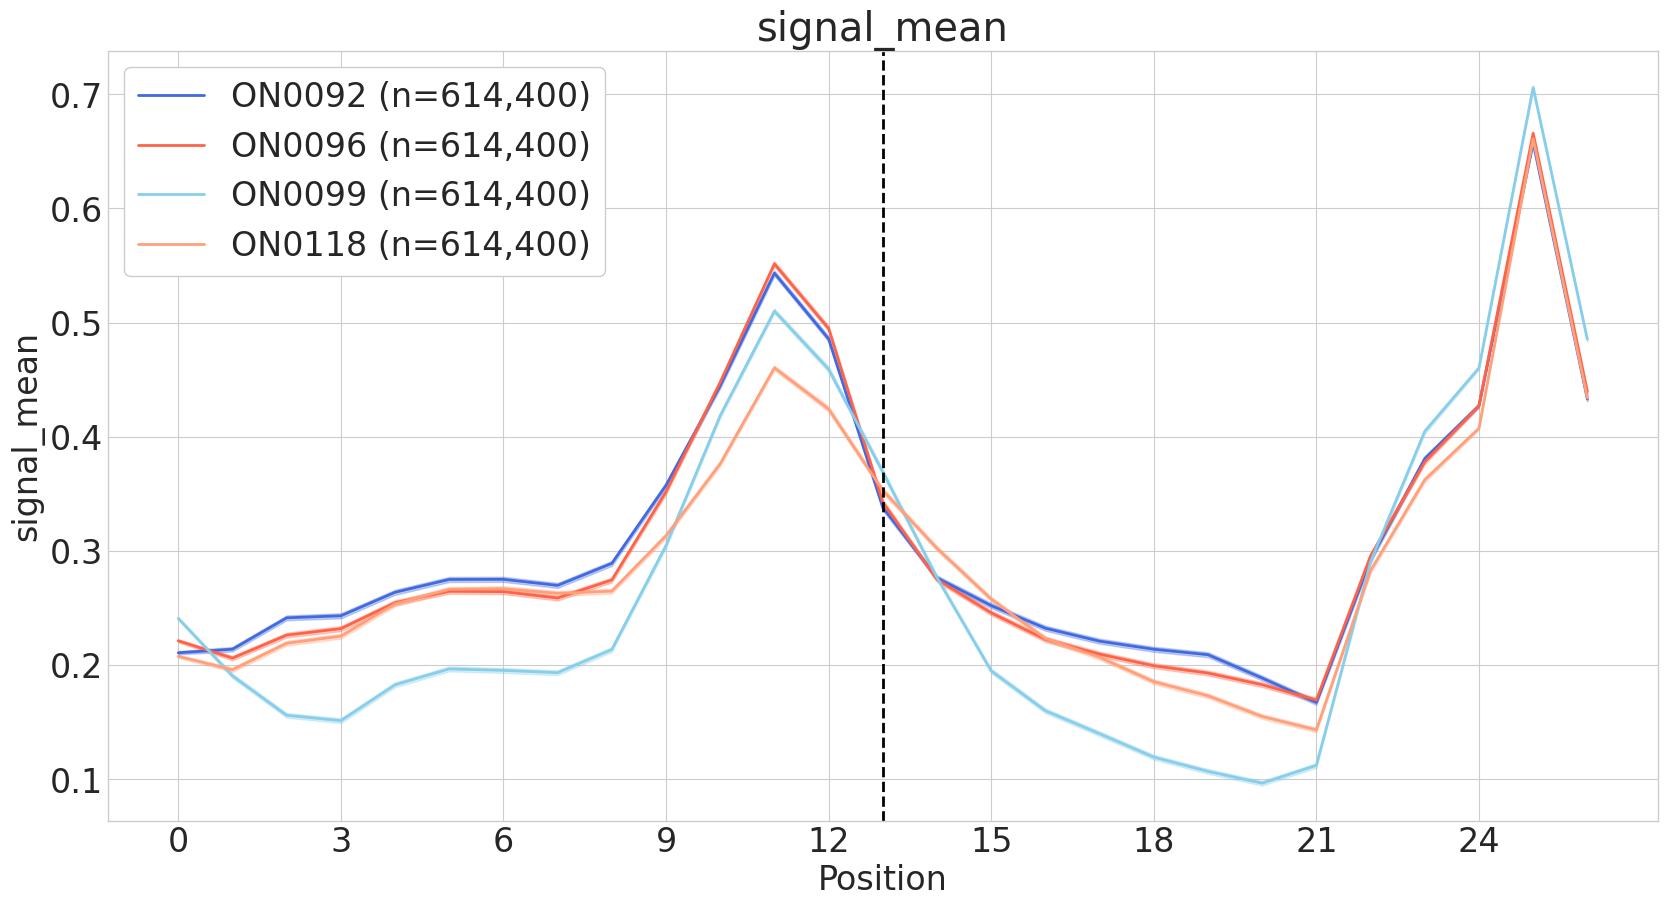

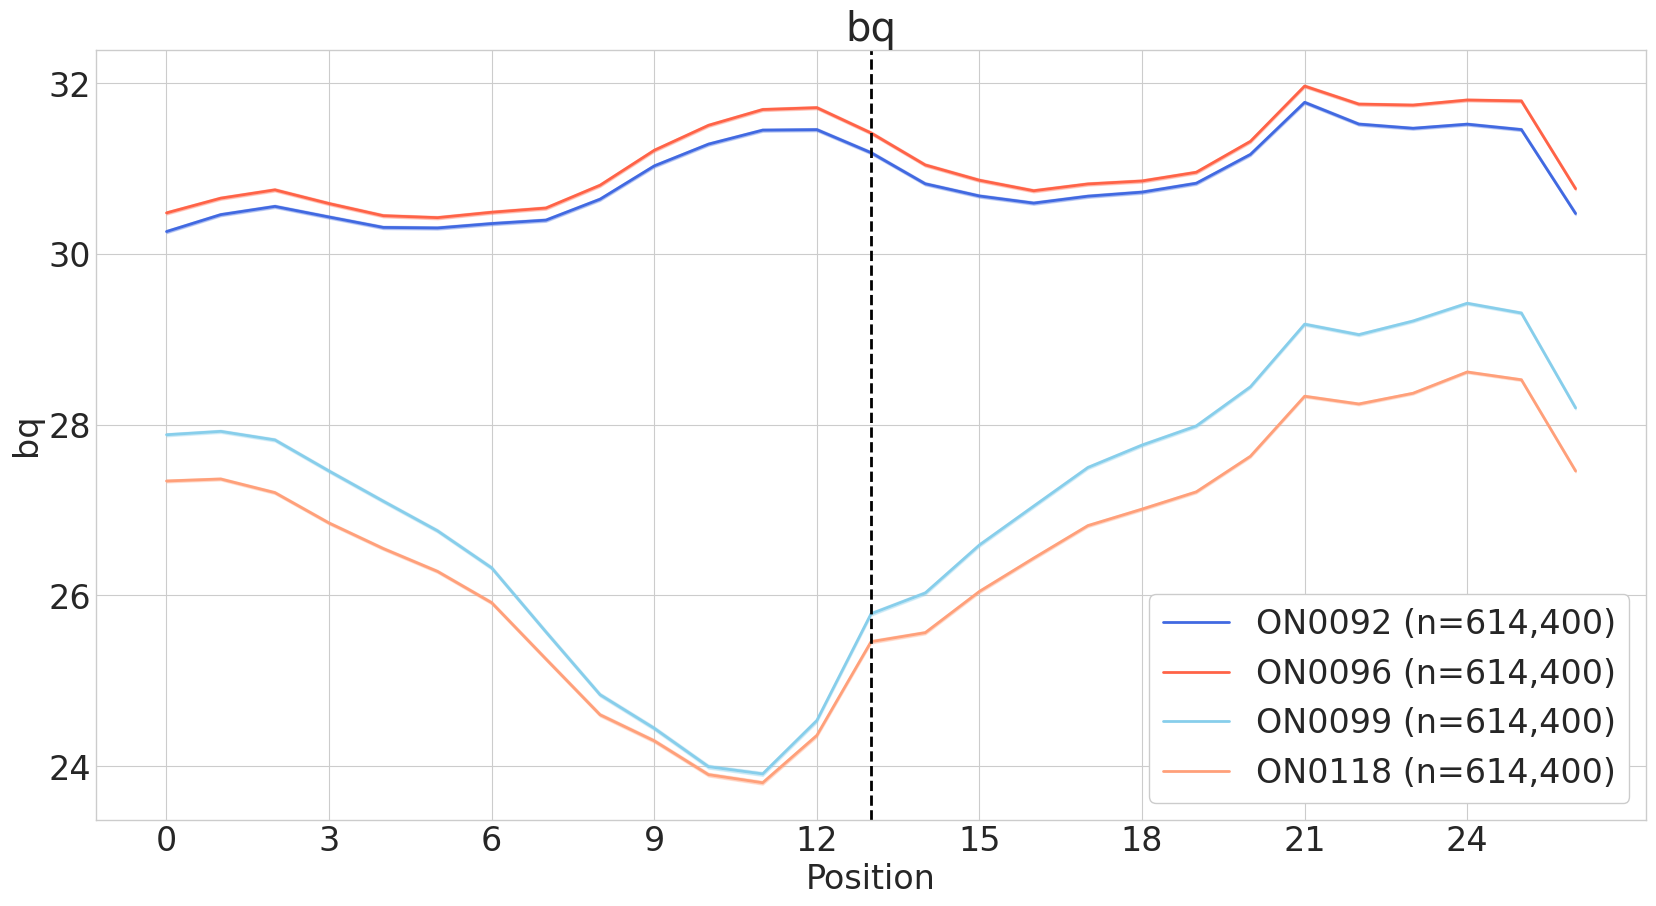

In [8]:
out_path = "/extdata4/baeklab/Hyeonseo/m6A/plot/feature_analysis"
os.makedirs(out_path, exist_ok = True)
for feature in ["signal_mean","bq"]:
    feature_renamed = f"{feature}"

    data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict.items()}

    mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
    ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
    length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}

    plot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)


In [9]:
out_path = "/extdata4/baeklab/Hyeonseo/m6A/plot/feature_analysis"
os.makedirs(out_path, exist_ok = True)

a_df = pd.concat([ON0092_df, ON0096_df]).copy().reset_index(drop=True)
m6a_df = pd.concat([ON0099_df, ON0118_df]).copy().reset_index(drop=True)

df_dict_2 = {"A": a_df,
             "m6A": m6a_df}

print(a_df)
print(m6a_df)

         index                                                 bq  \
0         1632  [28, 28, 29, 29, 35, 35, 35, 36, 37, 38, 40, 3...   
1          667  [30, 30, 34, 33, 33, 31, 31, 32, 33, 30, 34, 3...   
2         1125  [24, 24, 24, 27, 23, 23, 22, 22, 23, 34, 38, 3...   
3          299  [37, 38, 29, 27, 28, 32, 33, 33, 35, 35, 41, 4...   
4         1532  [31, 31, 31, 30, 31, 33, 33, 33, 34, 32, 32, 2...   
...        ...                                                ...   
1228795    799  [32, 18, 14, 12, 12, 12, 13, 13, 28, 28, 28, 2...   
1228796   1392  [33, 34, 35, 35, 36, 35, 35, 37, 38, 40, 43, 4...   
1228797    420  [40, 40, 41, 44, 45, 43, 42, 42, 35, 23, 19, 1...   
1228798   1125  [25, 25, 25, 26, 31, 36, 37, 37, 37, 38, 36, 3...   
1228799   1056  [26, 27, 28, 28, 28, 28, 28, 29, 26, 17, 16, 2...   

                         motif  cb_idx  \
0        CUGCGCCAAAAAAUCUGGCAG       0   
1        GCACGGGCAAAAAACCGGCAG       0   
2        UGAUUCUGAAAAAAAGCUCAG       0   
3  

In [11]:
print(a_df)
print(m6a_df)

         index                                                 bq  \
0         1632  [28, 28, 29, 29, 35, 35, 35, 36, 37, 38, 40, 3...   
1          667  [30, 30, 34, 33, 33, 31, 31, 32, 33, 30, 34, 3...   
2         1125  [24, 24, 24, 27, 23, 23, 22, 22, 23, 34, 38, 3...   
3          299  [37, 38, 29, 27, 28, 32, 33, 33, 35, 35, 41, 4...   
4         1532  [31, 31, 31, 30, 31, 33, 33, 33, 34, 32, 32, 2...   
...        ...                                                ...   
1228795    799  [32, 18, 14, 12, 12, 12, 13, 13, 28, 28, 28, 2...   
1228796   1392  [33, 34, 35, 35, 36, 35, 35, 37, 38, 40, 43, 4...   
1228797    420  [40, 40, 41, 44, 45, 43, 42, 42, 35, 23, 19, 1...   
1228798   1125  [25, 25, 25, 26, 31, 36, 37, 37, 37, 38, 36, 3...   
1228799   1056  [26, 27, 28, 28, 28, 28, 28, 29, 26, 17, 16, 2...   

                         motif  cb_idx  \
0        CUGCGCCAAAAAAUCUGGCAG       0   
1        GCACGGGCAAAAAACCGGCAG       0   
2        UGAUUCUGAAAAAAAGCUCAG       0   
3  

In [14]:
def get_centre_motif(motif):
    convert_dict = {"A": "R", "C": "Y", "G": "R", "U": "Y"}
    centre_motif = f"{convert_dict[motif[1]]}A{convert_dict[motif[3]]}"
    return centre_motif

In [15]:

a_df["centre_motif"] = a_df["motif"].apply(get_centre_motif)
m6a_df["centre_motif"] = m6a_df["motif"].apply(get_centre_motif)

for motif in ["RAR", "RAY", "YAR", "YAY"]:
    df_dict = {"A": a_df[a_df["centre_motif"]==motif],
               "m6A": m6a_df[m6a_df["centre_motif"]==motif]}
    for feature in ["bq", "signal_mean"]:
        feature_renamed = f"{feature}_{motif}"
        data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict.items()}
        mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
        ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
        length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}
        plot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)
    

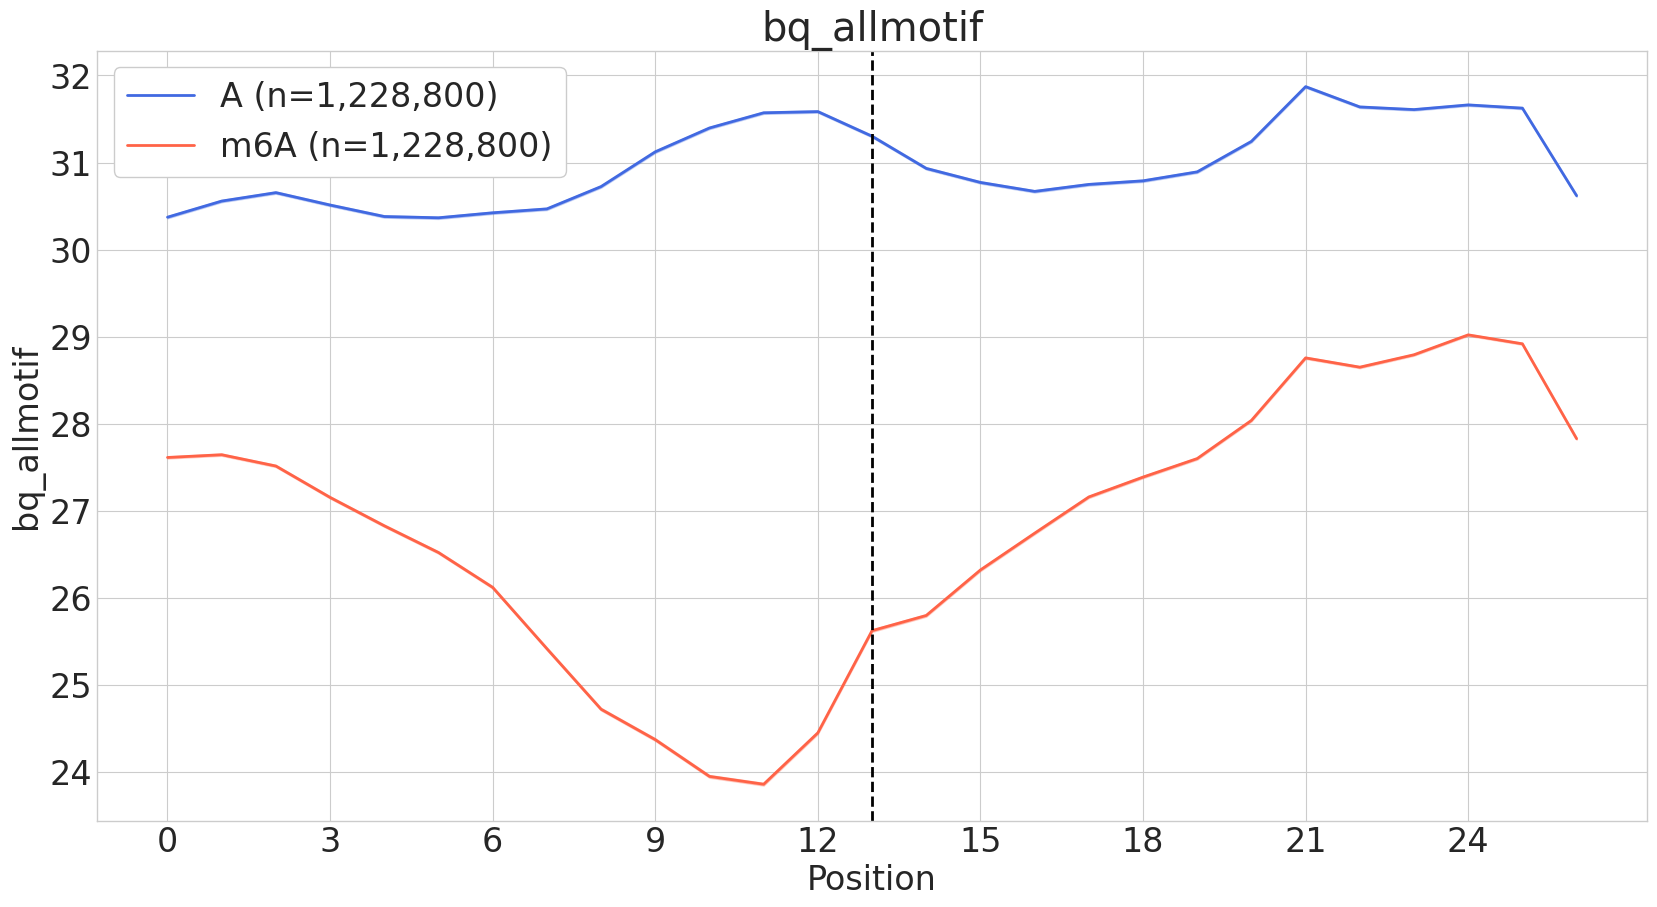

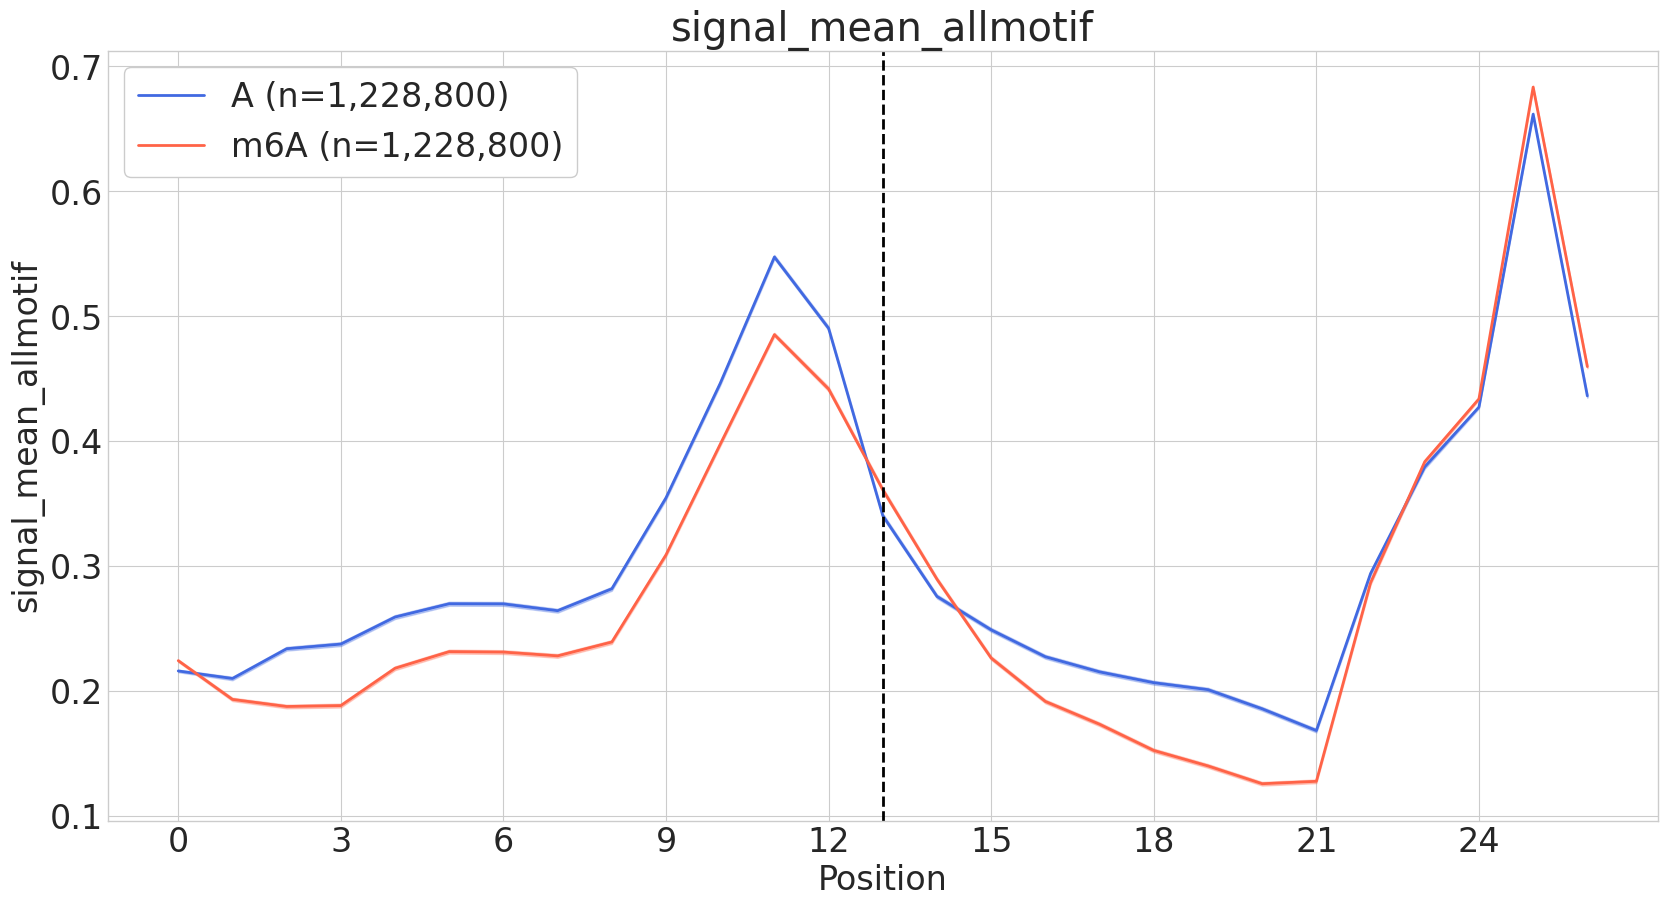

In [12]:
df_dict = {"A": a_df,
           "m6A": m6a_df}

for feature in ["bq", "signal_mean"]:
    feature_renamed = f"{feature}_allmotif"

    data_dict = {df_name: np.stack(df[feature].values) for df_name, df in df_dict.items()}

    mean_dict = {df_name: np.mean(data, axis=0) for df_name, data in data_dict.items()}
    ci95_dict = {df_name: 1.96*np.std(data, axis=0)/np.sqrt(data.shape[0]) for df_name, data in data_dict.items()}
    length_dict = {df_name: data.shape[0] for df_name, data in data_dict.items()}

    plot(mean_dict, ci95_dict, length_dict, feature_renamed, out_path)


In [32]:
print(df)

                                                  mv  \
0  [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [6, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   

                                read_id    ts       ns  sp  
0  c07ad39e-255c-434b-8860-f4d531c6548d  1400  1145708   0  
1  a1e1f55e-76ec-4687-a61a-993eae297f91  3050  2377920   0  
2  8e0e7432-65ff-4c58-a8d3-2fdb21392906  2650  2376421   0  
3  e6696f98-aa7a-4747-ae43-aeba9f93c884  4800  2195697   0  
